# TREC-DL attack table (LaTeX)

This notebook reads `attack_table.csv` and writes `attack_table.tex`. It keeps all model rows, but presents only **Default** (the normal evaluator prompt) and **Defense** (the marker-aware evaluator prompt) columns. Each populated cell is rendered as `ASR%` and `successes/valid`. The plots also read `attack_outcomes.csv` so Query Injection (QI) appears as its own attack block, including the separate **Defense QI** prompt, without changing the DOH/DCH comparison-table schema.

The generated table requires `booktabs`, `makecell`, `multirow`, and `graphicx` in the manuscript preamble.

In [45]:
import csv
import re
import statistics
from collections import defaultdict
from pathlib import Path

try:
    from IPython.display import Markdown, display
except ImportError:
    Markdown = None
    display = None


def find_repository_root(start=Path.cwd()):
    for candidate in (start, *start.parents):
        if (candidate / 'LLM_prompt_attack').is_dir():
            return candidate
    raise FileNotFoundError('Run this notebook from inside the repository.')


def latex_escape(value):
    return (
        value.replace('\\', r'\textbackslash{}')
        .replace('&', r'\&')
        .replace('%', r'\%')
        .replace('_', r'\_')
        .replace('#', r'\#')
    )


METRIC = re.compile(r'^(?P<rate>\d+(?:\.\d+)?)% \((?P<success>\d+)/(?P<valid>\d+)\)$')
GROUPS = (
    ('Pairwise Flipped %', r'Pairwise Flipped \%'),
    ('Setwise Attack Success %', r'Setwise Attack Success \%'),
    ('Listwise Attack Top Position %', r'Listwise Attack Top Position \%'),
)
ATTACKS = ('DOH', 'DCH')
MODES = (('Default', 'Ours'), ('Defense', 'Defense'))


def column_name(group, attack, source):
    return f'{group} | {attack} | {source}'


def parse_metric(value):
    match = METRIC.match((value or '').strip())
    if match is None:
        return None
    return float(match['rate']), match['success'], match['valid']


def latex_metric(value):
    parsed = parse_metric(value)
    if parsed is None:
        return '--'
    rate, success, valid = parsed
    return rf'\makecell[c]{{{rate:.2f}\%\\[-1pt]\scriptsize({success}/{valid})}}'


def latex_summary(rows, column):
    values = [parsed[0] for row in rows if (parsed := parse_metric(row.get(column)))]
    if not values:
        return '--'
    if len(values) == 1:
        return rf'{values[0]:.2f}\%'
    return rf'{statistics.mean(values):.2f}\% $\pm$ {statistics.stdev(values):.2f}'


root = find_repository_root()
csv_path = root / 'Results' / 'attack_table.csv'
tex_path = root / 'Results' / 'attack_table.tex'

with csv_path.open(encoding='utf-8', newline='') as csv_file:
    rows = list(csv.DictReader(csv_file))

datasets = defaultdict(list)
for row in rows:
    if row['Model'].startswith('Mean'):
        continue
    datasets[row['Dataset']].append(row)

lines = [
    r'\begin{table*}[t]',
    r'\centering',
    r'\small',
    r'\setlength{\tabcolsep}{3pt}',
    r'\caption{Attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}',
    r'\label{tab:trec-dl-attacks}',
    r'\resizebox{\textwidth}{!}{%',
    r'\begin{tabular}{ll*{12}{c}}',
    r'\toprule',
    r' & \textbf{Model} & \multicolumn{4}{c}{\textbf{Pairwise Flipped \%}} & \multicolumn{4}{c}{\textbf{Setwise Attack Success \%}} & \multicolumn{4}{c}{\textbf{Listwise Attack Top Position \%}} \\',
    r'\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}',
    r' & & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} \\',
    r' & & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\',
    r'\midrule',
]

for dataset_index, (dataset, dataset_rows) in enumerate(datasets.items()):
    for row_index, row in enumerate(dataset_rows):
        cells = []
        if row_index == 0:
            cells.append(rf'\multirow{{{len(dataset_rows) + 1}}}{{*}}{{\rotatebox{{90}}{{{latex_escape(dataset)}}}}}')
        else:
            cells.append('')
        cells.append(latex_escape(row['Model']))
        for group, _display in GROUPS:
            for attack in ATTACKS:
                for _mode, source in MODES:
                    cells.append(latex_metric(row.get(column_name(group, attack, source))))
        lines.append(' & '.join(cells) + r' \\')

    summary_cells = ['', r'\textbf{Mean $\pm$ Std}']
    for group, _display in GROUPS:
        for attack in ATTACKS:
            for _mode, source in MODES:
                summary_cells.append(latex_summary(dataset_rows, column_name(group, attack, source)))
    lines.append(r'\midrule')
    lines.append(' & '.join(summary_cells) + r' \\')
    if dataset_index != len(datasets) - 1:
        lines.append(r'\midrule')

lines.extend([r'\bottomrule', r'\end{tabular}', r'}', r'\end{table*}'])
latex_table = '\n'.join(lines) + '\n'
tex_path.write_text(latex_table, encoding='utf-8')

print(f'Wrote {tex_path.relative_to(root)}')
if display is None:
    print(latex_table)
else:
    display(Markdown(f'```latex\n{latex_table}\n```'))


Wrote Results\attack_table.tex


```latex
\begin{table*}[t]
\centering
\small
\setlength{\tabcolsep}{3pt}
\caption{Attack success rates for back-position injection on TREC-DL 2019 and 2020. Parentheses denote successes / valid outputs. Default uses the normal evaluator prompt; Defense uses the marker-aware evaluator prompt.}
\label{tab:trec-dl-attacks}
\resizebox{\textwidth}{!}{%
\begin{tabular}{ll*{12}{c}}
\toprule
 & \textbf{Model} & \multicolumn{4}{c}{\textbf{Pairwise Flipped \%}} & \multicolumn{4}{c}{\textbf{Setwise Attack Success \%}} & \multicolumn{4}{c}{\textbf{Listwise Attack Top Position \%}} \\
\cmidrule(lr){3-6} \cmidrule(lr){7-10} \cmidrule(lr){11-14}
 & & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} & \multicolumn{2}{c}{DOH} & \multicolumn{2}{c}{DCH} \\
 & & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense & Default & Defense \\
\midrule
\multirow{14}{*}{\rotatebox{90}{TREC-DL-2019}} & Qwen3-1.7B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-4B & \makecell[c]{81.74\%\\[-1pt]\scriptsize(3348/4096)} & \makecell[c]{69.95\%\\[-1pt]\scriptsize(2865/4096)} & \makecell[c]{76.37\%\\[-1pt]\scriptsize(3128/4096)} & \makecell[c]{10.89\%\\[-1pt]\scriptsize(446/4096)} & \makecell[c]{86.49\%\\[-1pt]\scriptsize(3522/4072)} & \makecell[c]{73.60\%\\[-1pt]\scriptsize(3013/4094)} & \makecell[c]{91.92\%\\[-1pt]\scriptsize(3743/4072)} & \makecell[c]{30.18\%\\[-1pt]\scriptsize(1233/4086)} & \makecell[c]{32.15\%\\[-1pt]\scriptsize(1316/4093)} & \makecell[c]{31.92\%\\[-1pt]\scriptsize(1262/3954)} & \makecell[c]{79.73\%\\[-1pt]\scriptsize(3264/4094)} & \makecell[c]{16.30\%\\[-1pt]\scriptsize(667/4092)} \\
 & Qwen3-8B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-14B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-32B & \makecell[c]{95.90\%\\[-1pt]\scriptsize(3928/4096)} & \makecell[c]{29.03\%\\[-1pt]\scriptsize(1189/4096)} & \makecell[c]{96.97\%\\[-1pt]\scriptsize(3972/4096)} & \makecell[c]{16.19\%\\[-1pt]\scriptsize(663/4096)} & \makecell[c]{90.10\%\\[-1pt]\scriptsize(3658/4060)} & \makecell[c]{79.74\%\\[-1pt]\scriptsize(3266/4096)} & \makecell[c]{95.57\%\\[-1pt]\scriptsize(3885/4065)} & \makecell[c]{75.37\%\\[-1pt]\scriptsize(3087/4096)} & \makecell[c]{53.11\%\\[-1pt]\scriptsize(1709/3218)} & \makecell[c]{33.72\%\\[-1pt]\scriptsize(1357/4024)} & \makecell[c]{97.33\%\\[-1pt]\scriptsize(3974/4083)} & \makecell[c]{74.40\%\\[-1pt]\scriptsize(3045/4093)} \\
 & Gemma-3-12B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Gemma-3-27B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3-8B & \makecell[c]{59.30\%\\[-1pt]\scriptsize(2429/4096)} & \makecell[c]{57.96\%\\[-1pt]\scriptsize(2374/4096)} & \makecell[c]{88.33\%\\[-1pt]\scriptsize(3618/4096)} & \makecell[c]{61.82\%\\[-1pt]\scriptsize(2532/4096)} & \makecell[c]{89.32\%\\[-1pt]\scriptsize(2784/3117)} & \makecell[c]{71.07\%\\[-1pt]\scriptsize(199/280)} & \makecell[c]{98.61\%\\[-1pt]\scriptsize(1981/2009)} & \makecell[c]{27.78\%\\[-1pt]\scriptsize(10/36)} & \makecell[c]{38.15\%\\[-1pt]\scriptsize(1178/3088)} & \makecell[c]{29.51\%\\[-1pt]\scriptsize(987/3345)} & \makecell[c]{81.40\%\\[-1pt]\scriptsize(2779/3414)} & \makecell[c]{92.41\%\\[-1pt]\scriptsize(1596/1727)} \\
 & Llama-3.3-70B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-4.1-mini & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-OSS-20B & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4060/4060)} & \makecell[c]{33.37\%\\[-1pt]\scriptsize(1300/3896)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4056/4056)} & \makecell[c]{7.04\%\\[-1pt]\scriptsize(239/3393)} & \makecell[c]{99.80\%\\[-1pt]\scriptsize(4011/4019)} & \makecell[c]{19.62\%\\[-1pt]\scriptsize(762/3884)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4041/4041)} & \makecell[c]{23.04\%\\[-1pt]\scriptsize(724/3143)} & \makecell[c]{21.45\%\\[-1pt]\scriptsize(145/676)} & \makecell[c]{6.63\%\\[-1pt]\scriptsize(106/1598)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4041/4041)} & \makecell[c]{23.02\%\\[-1pt]\scriptsize(464/2016)} \\
 & gpt-5.6-terra & -- & -- & -- & -- & \makecell[c]{8.00\%\\[-1pt]\scriptsize(8/100)} & -- & -- & -- & -- & -- & -- & -- \\
 & meta.llama3-70b-instruct-v1:0 & \makecell[c]{98.66\%\\[-1pt]\scriptsize(4041/4096)} & \makecell[c]{98.85\%\\[-1pt]\scriptsize(4049/4096)} & \makecell[c]{99.98\%\\[-1pt]\scriptsize(4095/4096)} & \makecell[c]{7.40\%\\[-1pt]\scriptsize(303/4096)} & \makecell[c]{97.39\%\\[-1pt]\scriptsize(3774/3875)} & \makecell[c]{67.38\%\\[-1pt]\scriptsize(2617/3884)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(3880/3880)} & \makecell[c]{13.09\%\\[-1pt]\scriptsize(517/3949)} & \makecell[c]{25.67\%\\[-1pt]\scriptsize(239/931)} & \makecell[c]{8.79\%\\[-1pt]\scriptsize(259/2947)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4014/4014)} & \makecell[c]{39.36\%\\[-1pt]\scriptsize(1561/3966)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 87.12\% $\pm$ 17.17 & 57.83\% $\pm$ 28.54 & 92.33\% $\pm$ 10.12 & 20.67\% $\pm$ 23.30 & 78.52\% $\pm$ 34.92 & 62.28\% $\pm$ 24.27 & 97.22\% $\pm$ 3.47 & 33.89\% $\pm$ 24.09 & 34.11\% $\pm$ 12.38 & 22.11\% $\pm$ 13.26 & 91.69\% $\pm$ 10.23 & 49.10\% $\pm$ 33.04 \\
\midrule
\multirow{13}{*}{\rotatebox{90}{TREC-DL-2020}} & Qwen3-1.7B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-4B & \makecell[c]{80.64\%\\[-1pt]\scriptsize(3303/4096)} & \makecell[c]{67.33\%\\[-1pt]\scriptsize(2758/4096)} & \makecell[c]{73.34\%\\[-1pt]\scriptsize(3004/4096)} & \makecell[c]{15.31\%\\[-1pt]\scriptsize(627/4096)} & \makecell[c]{83.80\%\\[-1pt]\scriptsize(3420/4081)} & \makecell[c]{72.04\%\\[-1pt]\scriptsize(2950/4095)} & \makecell[c]{89.83\%\\[-1pt]\scriptsize(3666/4081)} & \makecell[c]{30.45\%\\[-1pt]\scriptsize(1243/4082)} & \makecell[c]{31.11\%\\[-1pt]\scriptsize(1271/4086)} & \makecell[c]{32.66\%\\[-1pt]\scriptsize(1313/4020)} & \makecell[c]{80.60\%\\[-1pt]\scriptsize(3298/4092)} & \makecell[c]{17.38\%\\[-1pt]\scriptsize(711/4090)} \\
 & Qwen3-8B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-14B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Qwen3-32B & \makecell[c]{92.11\%\\[-1pt]\scriptsize(3773/4096)} & \makecell[c]{28.25\%\\[-1pt]\scriptsize(1157/4096)} & \makecell[c]{95.24\%\\[-1pt]\scriptsize(3901/4096)} & \makecell[c]{18.43\%\\[-1pt]\scriptsize(755/4096)} & \makecell[c]{87.87\%\\[-1pt]\scriptsize(3572/4065)} & \makecell[c]{77.29\%\\[-1pt]\scriptsize(3166/4096)} & \makecell[c]{95.55\%\\[-1pt]\scriptsize(3883/4064)} & \makecell[c]{73.88\%\\[-1pt]\scriptsize(3026/4096)} & \makecell[c]{53.54\%\\[-1pt]\scriptsize(1679/3136)} & \makecell[c]{34.26\%\\[-1pt]\scriptsize(1372/4005)} & \makecell[c]{97.45\%\\[-1pt]\scriptsize(3981/4085)} & \makecell[c]{74.86\%\\[-1pt]\scriptsize(3055/4081)} \\
 & Gemma-3-12B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Gemma-3-27B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & Llama-3-8B & \makecell[c]{60.11\%\\[-1pt]\scriptsize(2462/4096)} & \makecell[c]{56.59\%\\[-1pt]\scriptsize(2318/4096)} & \makecell[c]{86.77\%\\[-1pt]\scriptsize(3554/4096)} & \makecell[c]{60.30\%\\[-1pt]\scriptsize(2470/4096)} & \makecell[c]{86.43\%\\[-1pt]\scriptsize(2675/3095)} & \makecell[c]{79.61\%\\[-1pt]\scriptsize(164/206)} & \makecell[c]{96.95\%\\[-1pt]\scriptsize(2034/2098)} & \makecell[c]{66.67\%\\[-1pt]\scriptsize(10/15)} & \makecell[c]{38.76\%\\[-1pt]\scriptsize(1181/3047)} & \makecell[c]{32.17\%\\[-1pt]\scriptsize(1055/3279)} & \makecell[c]{77.10\%\\[-1pt]\scriptsize(1286/1668)} & \makecell[c]{91.90\%\\[-1pt]\scriptsize(1520/1654)} \\
 & Llama-3.3-70B & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-4.1-mini & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- & -- \\
 & GPT-OSS-20B & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4080/4080)} & \makecell[c]{37.09\%\\[-1pt]\scriptsize(1433/3864)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4082/4082)} & \makecell[c]{6.86\%\\[-1pt]\scriptsize(236/3439)} & \makecell[c]{99.68\%\\[-1pt]\scriptsize(4035/4048)} & \makecell[c]{15.64\%\\[-1pt]\scriptsize(618/3952)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4055/4055)} & \makecell[c]{23.47\%\\[-1pt]\scriptsize(736/3136)} & \makecell[c]{22.91\%\\[-1pt]\scriptsize(164/716)} & \makecell[c]{5.85\%\\[-1pt]\scriptsize(94/1607)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4062/4062)} & \makecell[c]{22.78\%\\[-1pt]\scriptsize(472/2072)} \\
 & meta.llama3-70b-instruct-v1:0 & \makecell[c]{97.80\%\\[-1pt]\scriptsize(4006/4096)} & \makecell[c]{97.97\%\\[-1pt]\scriptsize(4013/4096)} & \makecell[c]{100.00\%\\[-1pt]\scriptsize(4096/4096)} & \makecell[c]{6.15\%\\[-1pt]\scriptsize(252/4096)} & \makecell[c]{96.57\%\\[-1pt]\scriptsize(3776/3910)} & \makecell[c]{61.99\%\\[-1pt]\scriptsize(2437/3931)} & \makecell[c]{99.97\%\\[-1pt]\scriptsize(3922/3923)} & \makecell[c]{13.94\%\\[-1pt]\scriptsize(557/3997)} & \makecell[c]{21.45\%\\[-1pt]\scriptsize(180/839)} & \makecell[c]{8.68\%\\[-1pt]\scriptsize(258/2971)} & \makecell[c]{99.90\%\\[-1pt]\scriptsize(4037/4041)} & \makecell[c]{35.63\%\\[-1pt]\scriptsize(1423/3994)} \\
\midrule
 & \textbf{Mean $\pm$ Std} & 86.13\% $\pm$ 16.37 & 57.45\% $\pm$ 27.42 & 91.07\% $\pm$ 11.29 & 21.41\% $\pm$ 22.38 & 90.87\% $\pm$ 6.87 & 61.31\% $\pm$ 26.42 & 96.46\% $\pm$ 4.18 & 41.68\% $\pm$ 26.87 & 33.55\% $\pm$ 13.16 & 22.72\% $\pm$ 14.17 & 91.01\% $\pm$ 11.22 & 48.51\% $\pm$ 33.07 \\
\bottomrule
\end{tabular}
}
\end{table*}

```

## Default, defense, and Defense QI bar charts

This block plots every available Default, Defense, and Defense QI result in one figure per attack type: DOH, DCH, and Query Injection (QI) when results exist. Missing runs are omitted rather than represented as zero-height bars.

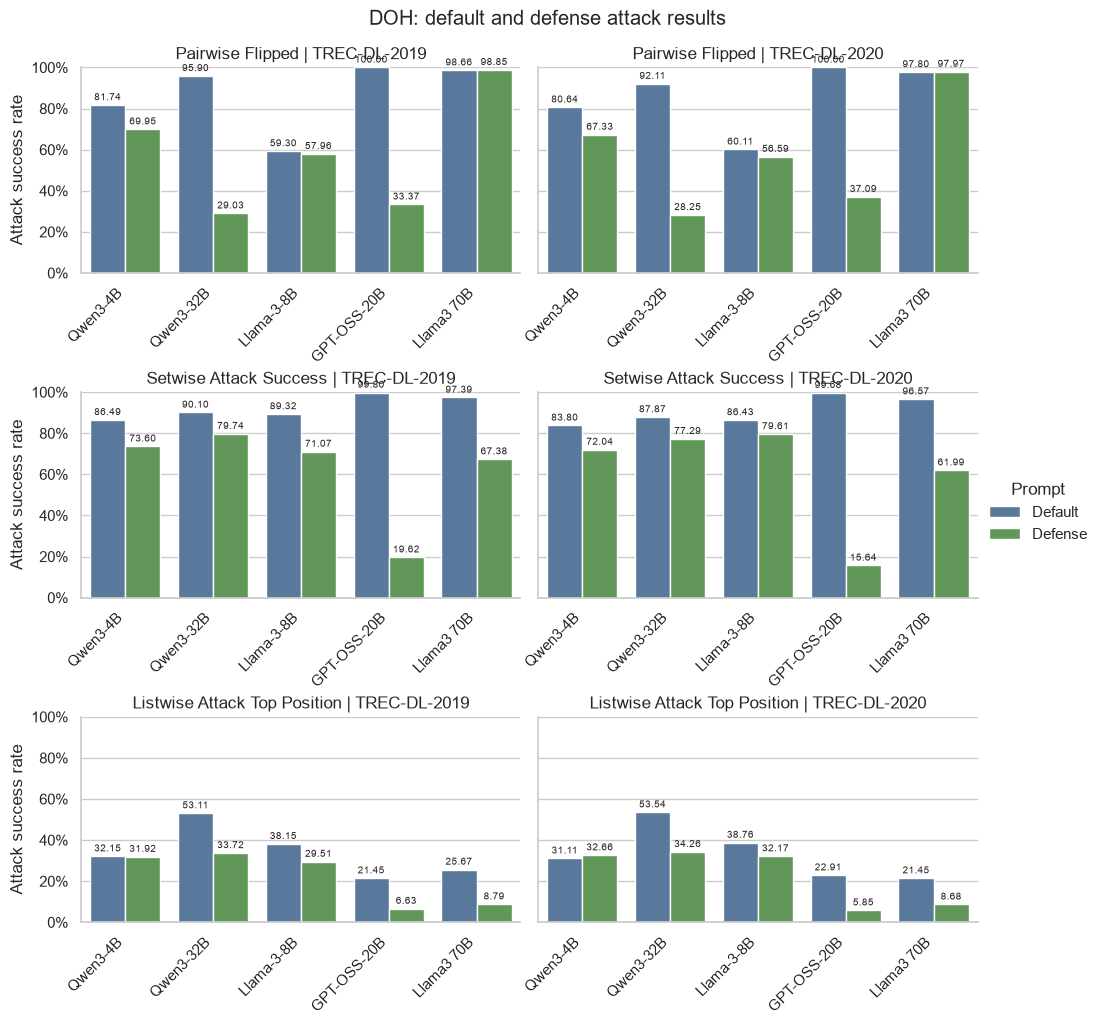

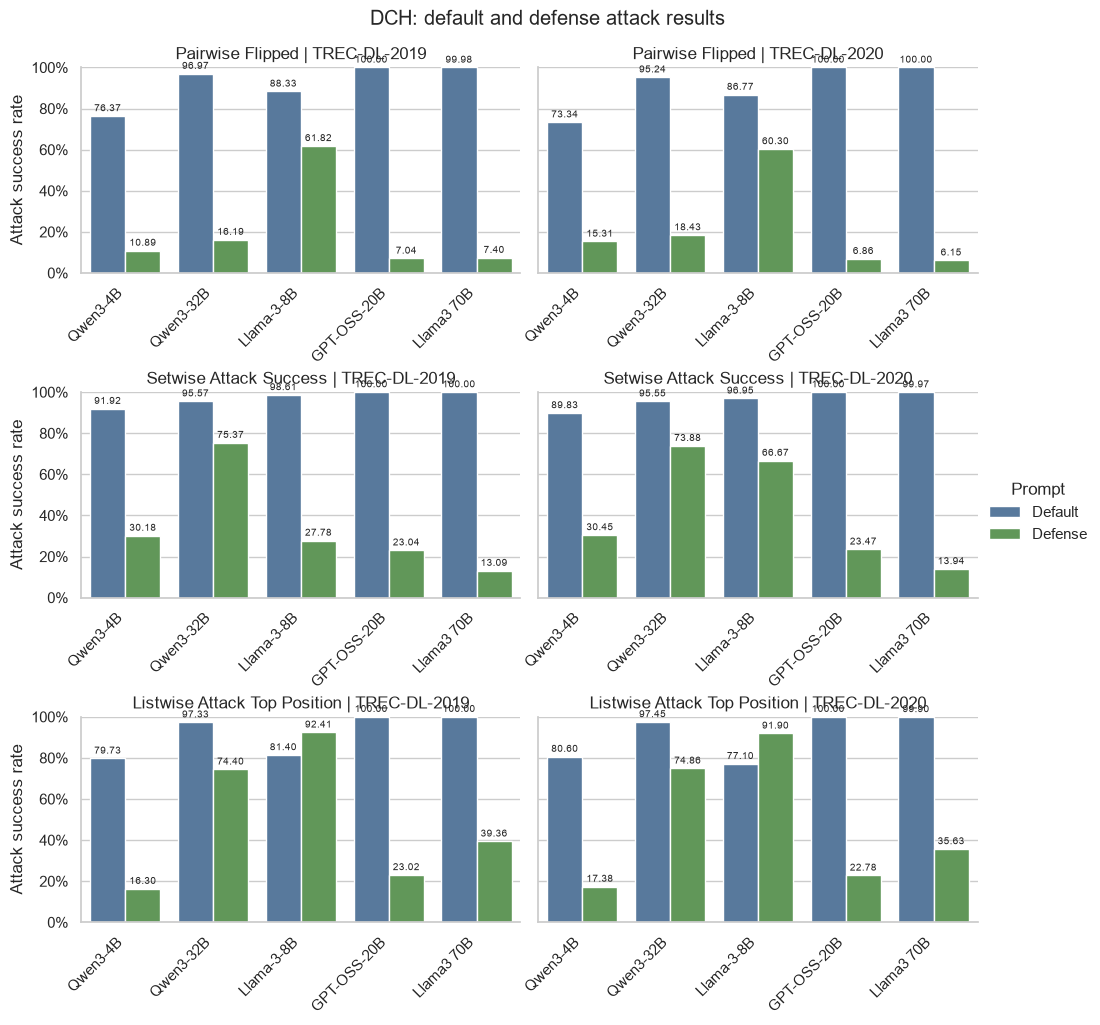

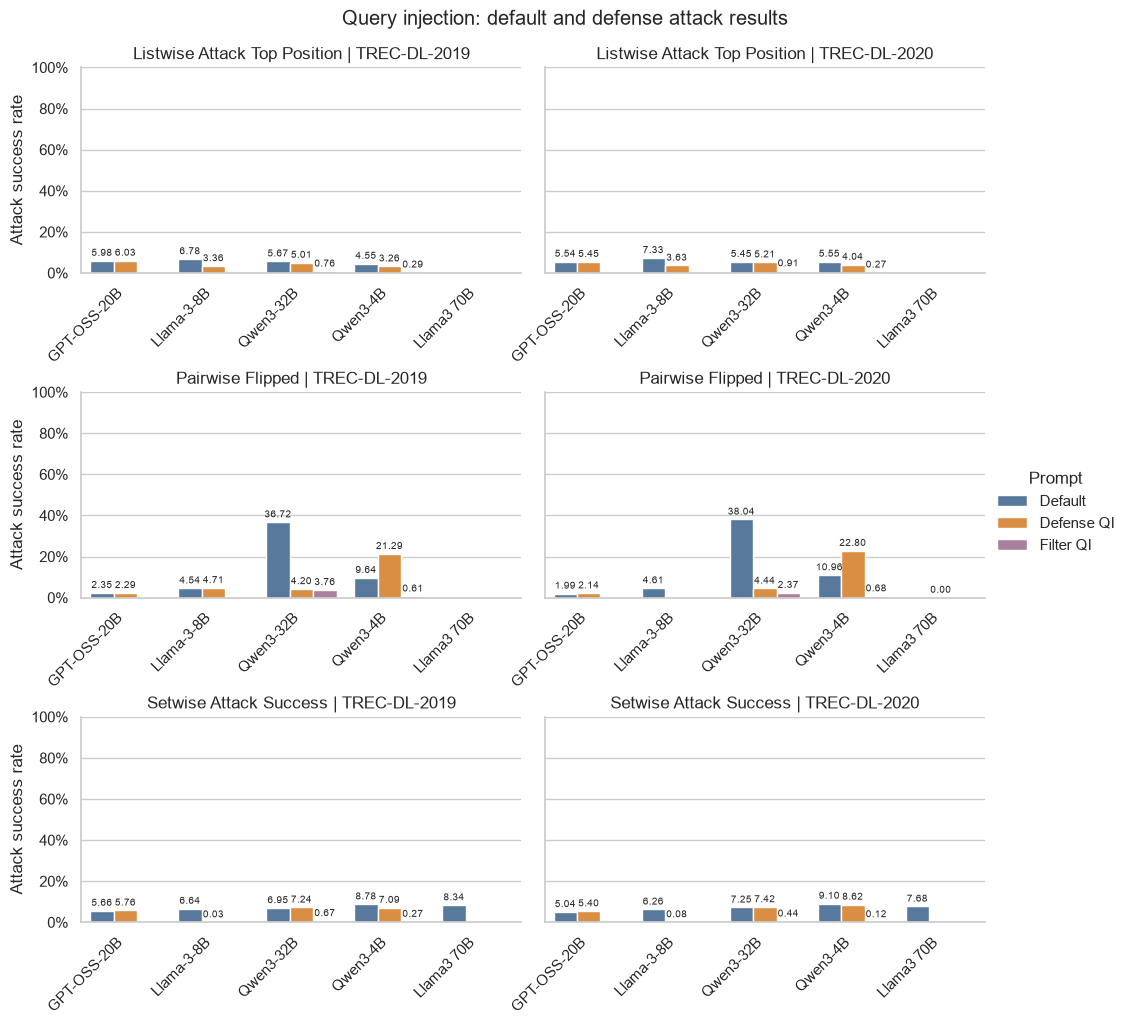

In [46]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.ticker import PercentFormatter

plot_records = []
for row in rows:
    if row['Model'].startswith('Mean') or row['Model'] == 'gpt-5.6-terra':
        continue
    for group, display_name in GROUPS:
        for attack in ATTACKS:
            for prompt, source in MODES:
                parsed = parse_metric(row.get(column_name(group, attack, source)))
                if parsed is None:
                    continue
                rate, _success, valid = parsed
                plot_records.append(
                    {
                        'Dataset': row['Dataset'],
                        'Model': {'meta.llama3-70b-instruct-v1:0': 'Llama3 70B'}.get(row['Model'], row['Model']),
                        'Paradigm': display_name.replace(r' \%', ''),
                        'Attack': attack,
                        'Prompt': prompt,
                        'ASR (%)': rate,
                        'Malformed / skipped (%)': (4096 - int(valid)) / 4096 * 100,
                    }
                )

plot_data = pd.DataFrame(plot_records)
outcomes_path = root / 'Results' / 'attack_outcomes.csv'
if outcomes_path.exists():
    qi_data = pd.read_csv(outcomes_path)
    qi_data = qi_data[
        qi_data['Attack'].eq('Query injection')
        & qi_data['Model'].ne('gpt-5.6-terra')
        & qi_data['Prompt'].isin(['Default', 'Defense QI', 'Filter QI'])
        & qi_data['Valid attacked'].gt(0)
    ].copy()
    if not qi_data.empty:
        qi_data['Model'] = qi_data['Model'].replace(
            {'meta.llama3-70b-instruct-v1:0': 'Llama3 70B'}
        )
        qi_data['Paradigm'] = qi_data['Paradigm'].map(
            {
                'Pairwise': 'Pairwise Flipped',
                'Setwise': 'Setwise Attack Success',
                'Listwise': 'Listwise Attack Top Position',
            }
        )
        qi_data['ASR (%)'] = (
            qi_data['Attack success'] / qi_data['Valid attacked'] * 100
        )
        qi_data['Malformed / skipped (%)'] = qi_data['Discarded (%)']
        plot_data = pd.concat(
            [
                plot_data,
                qi_data[
                    [
                        'Dataset',
                        'Model',
                        'Paradigm',
                        'Attack',
                        'Prompt',
                        'ASR (%)',
                        'Malformed / skipped (%)',
                    ]
                ],
            ],
            ignore_index=True,
        )
if plot_data.empty:
    print('No attack results are available to plot.')
else:
    sns.set_theme(style='whitegrid', context='notebook')
    for attack, attack_data in plot_data.groupby('Attack', sort=False):
        prompt_order = ['Default', 'Defense QI', 'Filter QI'] if attack == 'Query injection' else ['Default', 'Defense']
        chart = sns.catplot(
            data=attack_data,
            kind='bar',
            x='Model',
            y='ASR (%)',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=list(dict.fromkeys(attack_data['Model'])),
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('', 'Attack success rate')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle(f'{attack}: default and defense attack results', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [f'{bar.get_height():.2f}' for bar in container]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        slug = attack.lower().replace(' ', '_')
        plt.show()


## ASR with consideration of invalid attacks

These charts treat invalid or skipped attacked rankings as failed attacks. They therefore calculate ASR as successful attacks divided by all requested passages in the run. Results are separated by attack type and compare Default, Defense, and Defense QI when available.

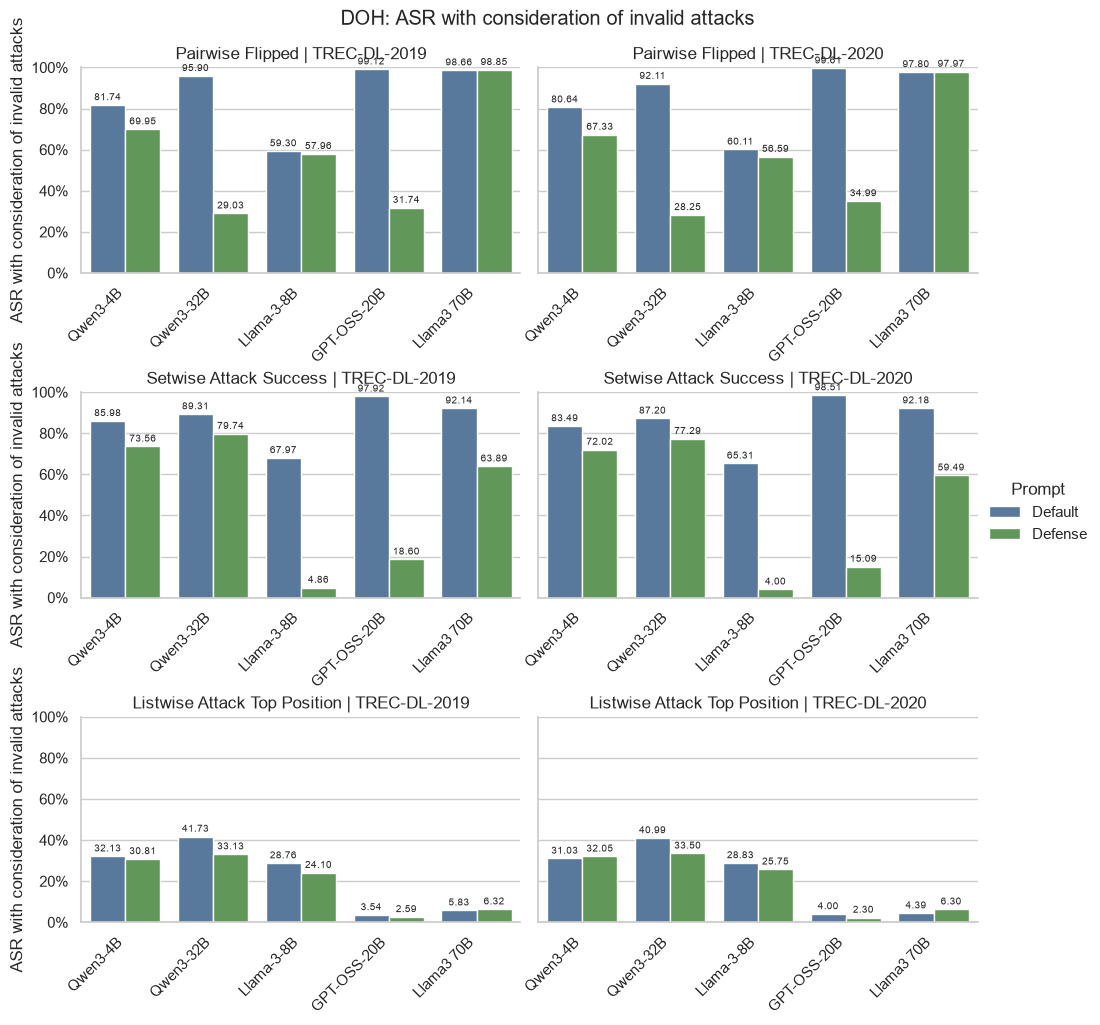

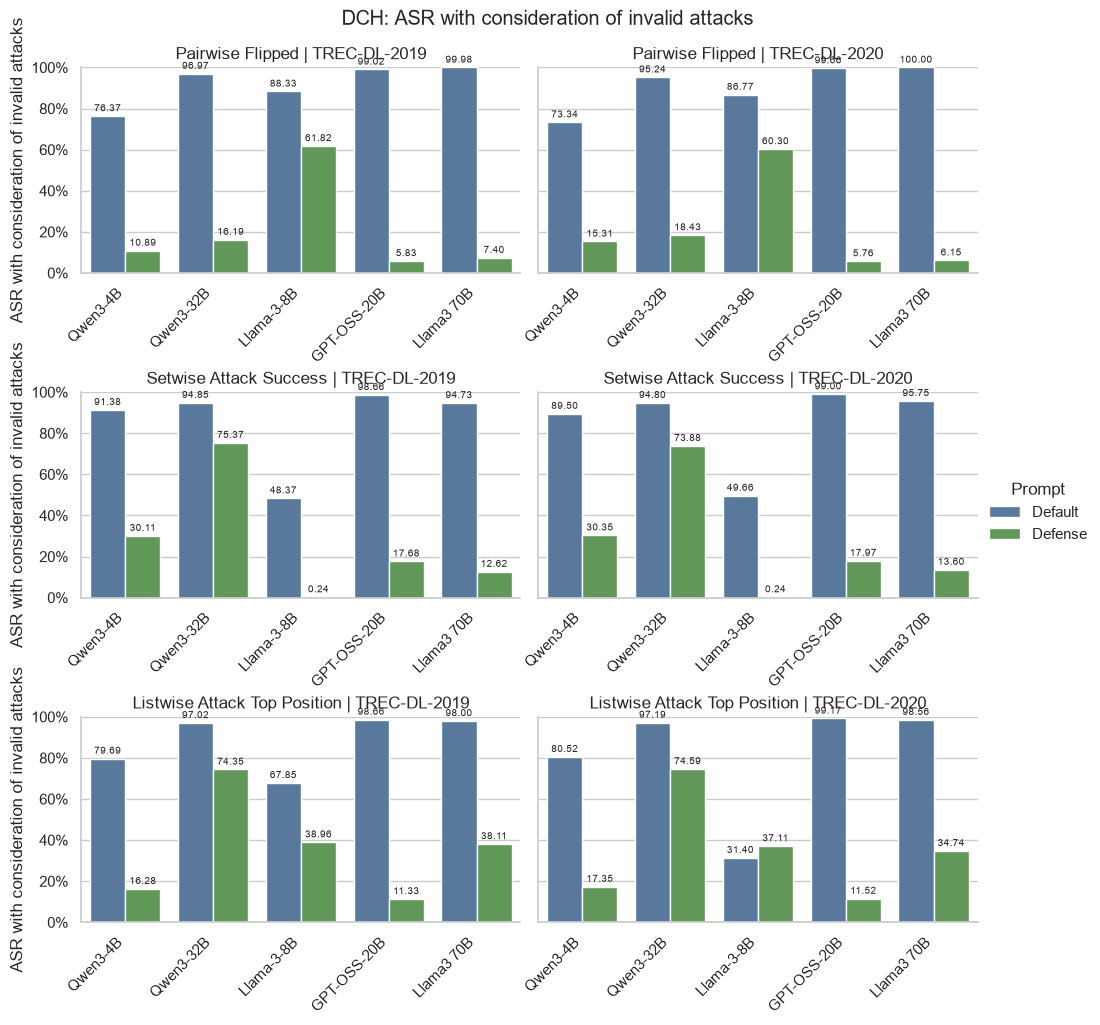

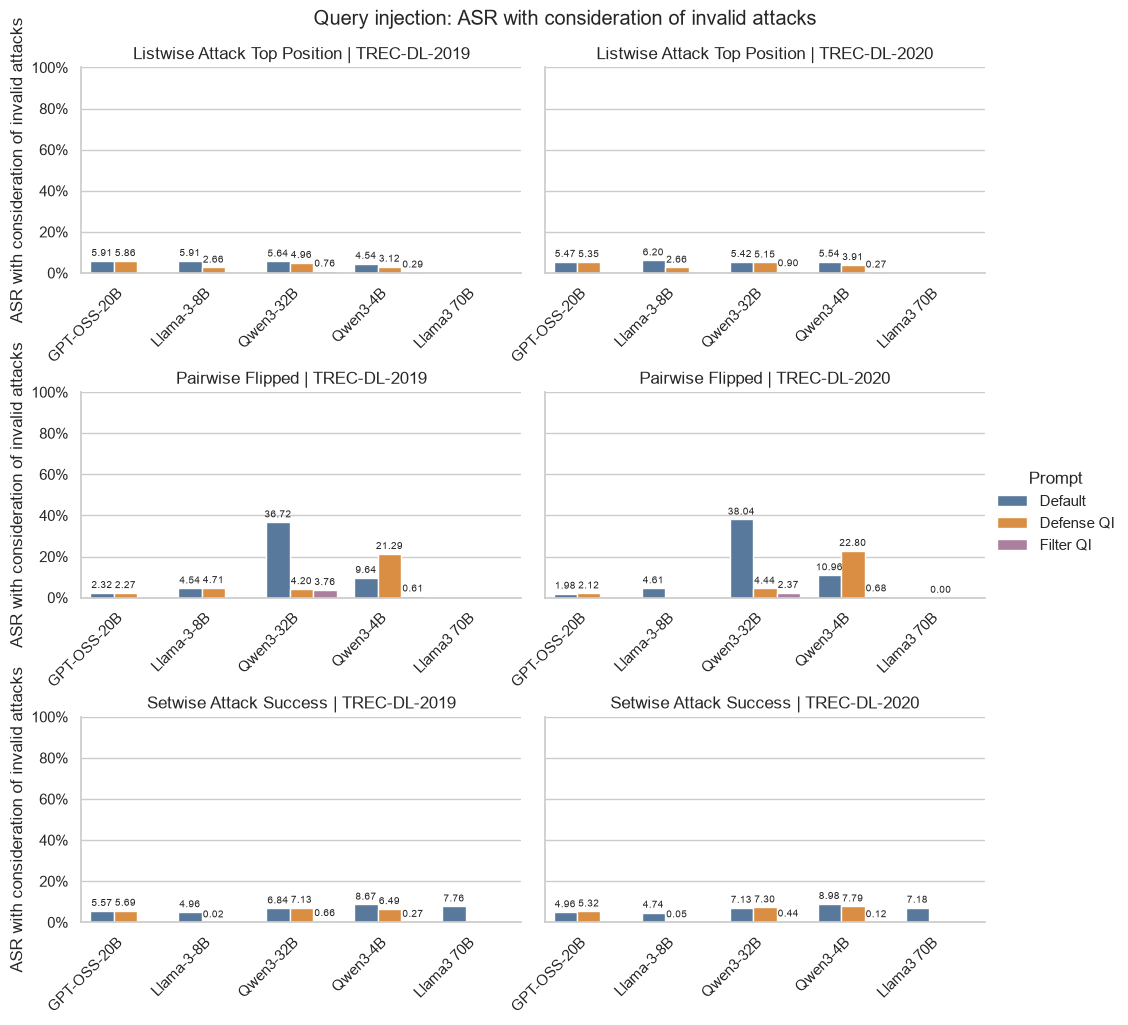

In [47]:
full_run_data = plot_data.assign(
    **{
        'ASR with invalid attacks (%)': plot_data['ASR (%)']
        * (1 - plot_data['Malformed / skipped (%)'] / 100)
    }
)

if full_run_data.empty:
    print('No attack results are available to plot.')
else:
    for attack, attack_data in full_run_data.groupby('Attack', sort=False):
        prompt_order = ['Default', 'Defense QI', 'Filter QI'] if attack == 'Query injection' else ['Default', 'Defense']
        chart = sns.catplot(
            data=attack_data,
            kind='bar',
            x='Model',
            y='ASR with invalid attacks (%)',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=list(dict.fromkeys(attack_data['Model'])),
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('', 'ASR with consideration of invalid attacks')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle(f'{attack}: ASR with consideration of invalid attacks', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [
                    f'{bar.get_height():.2f}'
                    for bar in container
                ]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        slug = attack.lower().replace(' ', '_')
        plt.show()


## Close attack (Query Injection)

Close attack is reported separately because it uses closer relevance grades: 3/2 for pairwise and 3/2/2/2 for setwise and listwise. It is therefore not directly comparable with the standard 3/0 DOH/DCH table above. Run `Results/update_close_attack_table.py` after adding completed close-attack output files to refresh the source CSV.


,Dataset,Model,Paradigm,Prompt,Success %,Success,Valid,Requested,Malformed / skipped (%)
2,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Listwise,Default,7.08,290,3996,4096,2.441406
0,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Listwise,Defense,7.89,323,3920,4096,4.296875
1,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Listwise,Defense QI,6.52,267,3885,4096,5.151367
5,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Pairwise,Default,8.28,339,4023,4096,1.782227
3,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Pairwise,Defense,10.45,428,4042,4096,1.318359
4,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Pairwise,Defense QI,9.67,396,4039,4096,1.391602
8,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Setwise,Default,6.45,264,3985,4096,2.709961
6,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Setwise,Defense,5.83,239,4004,4096,2.246094
7,msmarco-passage/trec-dl-2019,openai.gpt-oss-20b-1:0,Setwise,Defense QI,7.81,320,4022,4096,1.806641
10,msmarco-passage/trec-dl-2020,openai.gpt-oss-20b-1:0,Listwise,Default,7.35,301,4049,4096,1.147461


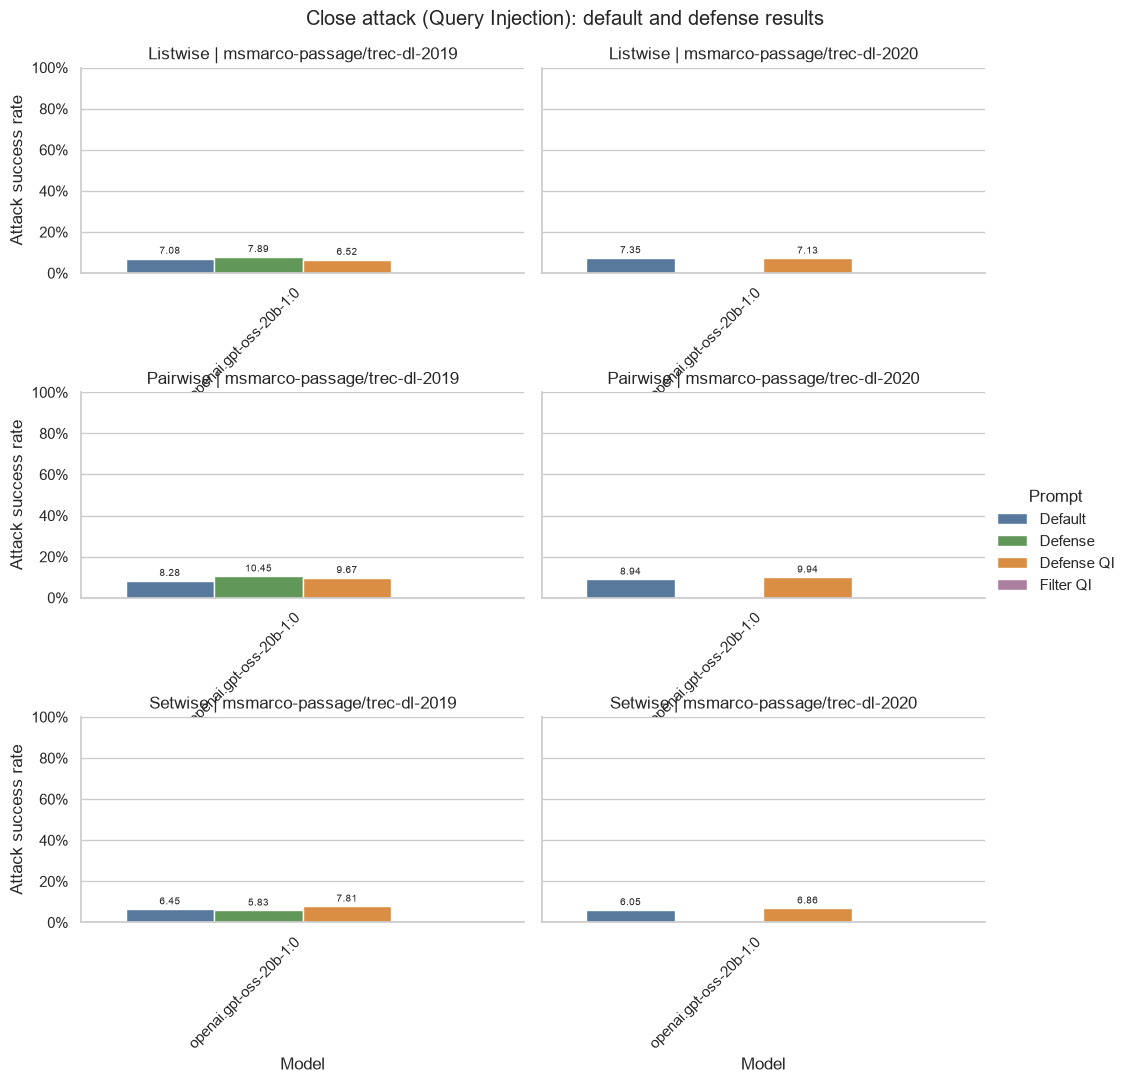

In [48]:
close_attack_path = root / 'Results' / 'close_attack_table.csv'
if not close_attack_path.exists():
    print('No close-attack summary found. Run Results/update_close_attack_table.py first.')
else:
    close_data = pd.read_csv(close_attack_path)
    close_data['Prompt'] = close_data['Prompt'].replace({
        'standard': 'Default',
        'defense': 'Defense',
        'defense_qi': 'Defense QI',
        'filter_qi': 'Filter QI',
    })
    close_data['Model'] = close_data['Model'].replace({
        'meta.llama3-70b-instruct-v1:0': 'Llama3 70B',
    })
    close_data['Paradigm'] = close_data['Paradigm'].str.title()
    close_data['Success %'] = pd.to_numeric(close_data['Success %'])
    close_data['Valid'] = pd.to_numeric(close_data['Valid'])
    close_data['Malformed / skipped (%)'] = (4096 - close_data['Valid']) / 4096 * 100

    display(close_data.sort_values(['Dataset', 'Paradigm', 'Model', 'Prompt']))

    close_plot_data = close_data[close_data['Valid'].gt(0)].copy()
    if close_plot_data.empty:
        print('No valid close-attack results are available to plot.')
    else:
        prompt_order = ['Default', 'Defense', 'Defense QI', 'Filter QI']
        chart = sns.catplot(
            data=close_plot_data,
            kind='bar',
            x='Model',
            y='Success %',
            hue='Prompt',
            hue_order=prompt_order,
            col='Dataset',
            row='Paradigm',
            order=list(dict.fromkeys(close_plot_data['Model'])),
            palette={'Default': '#4C78A8', 'Defense': '#59A14F', 'Defense QI': '#F28E2B', 'Filter QI': '#B279A2'},
            errorbar=None,
            height=3.2,
            aspect=1.55,
            sharey=True,
        )
        chart.set_axis_labels('Model', 'Attack success rate')
        chart.set_titles('{row_name} | {col_name}')
        chart.figure.suptitle('Close attack (Query Injection): default and defense results', y=1.02)
        for axis in chart.axes.flat:
            for container in axis.containers:
                labels = [f'{bar.get_height():.2f}' for bar in container]
                axis.bar_label(container, labels=labels, padding=2, fontsize=7)
            axis.set_ylim(0, 100)
            axis.yaxis.set_major_formatter(PercentFormatter(xmax=100))
            axis.tick_params(axis='x', labelbottom=True, labelrotation=45)
            for label in axis.get_xticklabels():
                label.set_horizontalalignment('right')
        chart.figure.subplots_adjust(hspace=0.58)
        plt.show()
